In [ ]:
# Imports and config

import os
import warnings

import gspread
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from google.oauth2.service_account import Credentials

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Display configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

warnings.filterwarnings("ignore")

In [ ]:
# Data ingestion

load_dotenv()

SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets"
]

credentials = Credentials.from_service_account_file(
    "credentials.json",
    scopes=SCOPES
)

client = gspread.authorize(credentials)

sheet_id = os.getenv("SHEET_ID")

worksheet = (
    client
    .open_by_key(sheet_id)
    .worksheet("Public")
)

# Load all columns from the Google Sheet.
data = worksheet.get_all_records()

df = pd.DataFrame(data)

print(
    f"Dataset loaded successfully: "
    f"{df.shape[0]:,} rows × {df.shape[1]:,} columns"
)

display(df.head())


Dataset loaded successfully: 228 rows × 19 columns


,BookID,Title,Author,Original_Start,Start_Day,Start_Month,Start_Year,Start_Precision,Original_Finish,Finish_Day,Finish_Month,Finish_Year,Finish_Precision,Status,Language,Publisher,Publish_Year,Type,Notes
0,B0001,The stranger,Albert Camus,??-??-2024,,,2024,year,??-??-2024,,,2024,year,Read,English,Unknown,1946,Book,i liked the main character and found him to be very relatable in mannerisms
1,B0002,American Psycho,Bret Easton Ellis,??-??-2025,,,2025,year,??-??-2025,,,2025,year,Read,English,Vintage Books,1991,Book,this slapped but the movie sucked. edit: the movie didn't suck as much as i thought it did. ther...
2,B0003,Strange case of Dr Jekyll and Mr Hyde,Robert Louis Stevenson,26-05-2025,26,5,2025,exact,28-05-2025,28,5,2025,exact,Read,English,"London, Longmans Green and Co",1886,Book,"thought it was interesting. i liked the characters, even though it was very short they had a lot..."
3,B0004,Pakistan: Between the mosque and military,Husain Haqqani,,,,,unknown,,,,,unknown,To Be Read,English,,,Book,
4,B0005,斜陽,太宰治,,,,,unknown,,,,,unknown,To Be Read,Japanese,,,Book,


## Data Dictionary

| Variable | Description |
|---|---|
| `BookID` | Unique book identifier |
| `Title` | Book title |
| `Author` | Book author |
| `Original_Start` | Original recorded start date |
| `Start_Day` | Analytical start day |
| `Start_Month` | Analytical start month |
| `Start_Year` | Analytical start year |
| `Start_Precision` | Precision of start date |
| `Original_Finish` | Original recorded completion date |
| `Finish_Day` | Analytical completion day |
| `Finish_Month` | Analytical completion month |
| `Finish_Year` | Analytical completion year |
| `Finish_Precision` | Precision of completion date |
| `Status` | Reading status |
| `Language` | Book language |
| `Publisher` | Publisher |
| `Publish_Year` | Publication year |
| `Type` | Record type |
| `Notes` | Personal reading notes |

`Original_Start` and `Original_Finish` are retained for data auditing, while the analytical day/month/year/precision variables are used for quantitative date analysis.

In [ ]:
# Data standardisation

# Remove leading/trailing whitespace from every string cell.

df = df.map(
    lambda value: value.strip()
    if isinstance(value, str)
    else value
)

print("Whitespace standardisation completed.")

Whitespace standardisation completed.


In [ ]:
# Data quality assessment

print("Dataset dimensions:")
print(f"Rows:    {len(df):,}")
print(f"Columns: {len(df.columns):,}")

print("\nDuplicate BookIDs:")
print(df["BookID"].duplicated().sum())

print("\nMissing values:")
missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[
        missing_summary > 0
    ].to_frame("Missing_Count")
)

Dataset dimensions:
Rows:    228
Columns: 19

Duplicate BookIDs:
0

Missing values:


,Missing_Count


In [ ]:
# Data type standardisation

numeric_columns = [
    "Start_Day",
    "Start_Month",
    "Start_Year",
    "Finish_Day",
    "Finish_Month",
    "Finish_Year",
    "Publish_Year"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df.dtypes)

BookID                  str
Title                   str
Author                  str
Original_Start          str
Start_Day           float64
Start_Month         float64
Start_Year          float64
Start_Precision         str
Original_Finish         str
Finish_Day          float64
Finish_Month        float64
Finish_Year         float64
Finish_Precision        str
Status                  str
Language                str
Publisher               str
Publish_Year        float64
Type                    str
Notes                   str
dtype: object


In [ ]:
# Analytical completion year

books_read = df.copy()

# Standardise reading status

books_read["Status"] = (
    books_read["Status"]
    .astype("string")
    .str.strip()
)

# Create analytical completion year
#
# Start with the known Finish_Year values.
#
# Read + missing Finish_Year:
#     -> 0.0 = unknown completion year
#
# Unread + missing Finish_Year:
#     -> remains NaN and will not enter the completed-books analytical population.

books_read["Reading_Year"] = (
    books_read["Finish_Year"]
)

books_read.loc[
    books_read["Status"].eq("Read")
    & books_read["Finish_Year"].isna(),
    "Reading_Year"
] = 0.0


In [ ]:
# Completed books analytical population

books_read = books_read[
    books_read["Status"].eq("Read")
].copy()

print(
    f"Completed books: {len(books_read):,}"
)

print(
    f"Known completion year: "
    f"{books_read['Reading_Year'].gt(0).sum():,}"
)

print(
    f"Unknown completion year: "
    f"{books_read['Reading_Year'].eq(0).sum():,}"
)


Completed books: 58
Known completion year: 29
Unknown completion year: 29


In [ ]:
# Validate analytical year

unknown_year_books = books_read[
    books_read["Reading_Year"].eq(0)
]

display(
    unknown_year_books[
        [
            "BookID",
            "Title",
            "Status",
            "Original_Finish",
            "Finish_Year",
            "Reading_Year"
        ]
    ]
)


,BookID,Title,Status,Original_Finish,Finish_Year,Reading_Year
16,B0017,The count of Monte Cristo (abridged),Read,??-??-????,NaN,0.00
88,B0089,Wuthering heights (abridged),Read,??-??-????,NaN,0.00
94,B0095,The little prince,Read,??-??-????,NaN,0.00
98,B0099,うみべの女の子,Read,??-??-????,NaN,0.00
100,B0101,The alchemist,Read,??-??-????,NaN,0.00
103,B0104,惡の華,Read,??-??-????,NaN,0.00
104,B0105,おかえりアリス,Read,??-??-????,NaN,0.00
105,B0106,Homunculus,Read,??-??-????,NaN,0.00
106,B0107,殺し屋１ Ichi the killer,Read,??-??-????,NaN,0.00
107,B0108,残響 Zankyou,Read,??-??-????,NaN,0.00


In [229]:
# Check that no unread books entered the completed population.

assert books_read["Status"].eq("Read").all()

print(
    "Validation passed: all records in books_read have Status == 'Read'."
)


Validation passed: all records in books_read have Status == 'Read'.


In [ ]:
# Reading status distribution

status_counts = (
    df["Status"]
    .value_counts()
    .reset_index()
)

status_counts.columns = [
    "Status",
    "Count"
]

display(status_counts)


,Status,Count
0,To Be Read,166
1,Read,58
2,Dropped,2
3,Reading,2


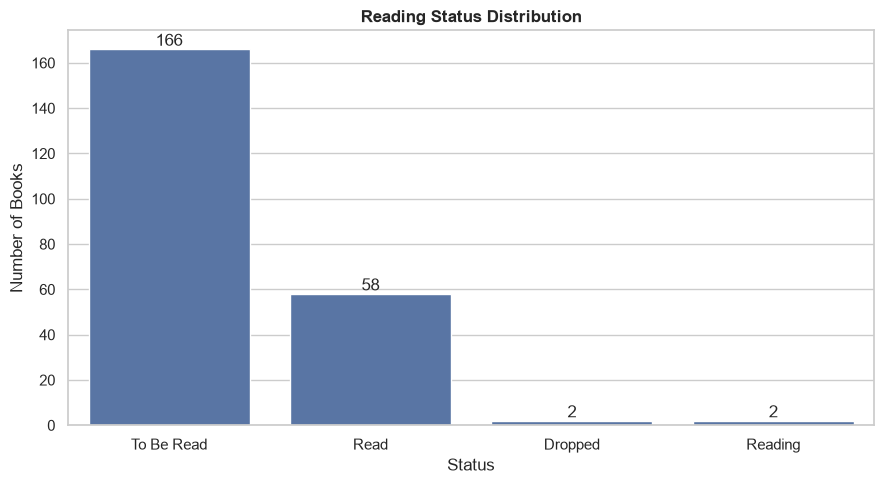

In [ ]:
# Status distribution visualisation

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=status_counts,
    x="Status",
    y="Count"
)

plt.title(
    "Reading Status Distribution",
    fontweight="bold"
)

plt.xlabel("Status")
plt.ylabel("Number of Books")

# Add values above bars.
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


In [ ]:
# Language distribution

language_counts = (
    df["Language"]
    .value_counts()
)

display(
    language_counts.to_frame("Books")
)


,Books
Language,
English,142
Japanese,55
,28
Bengali,3


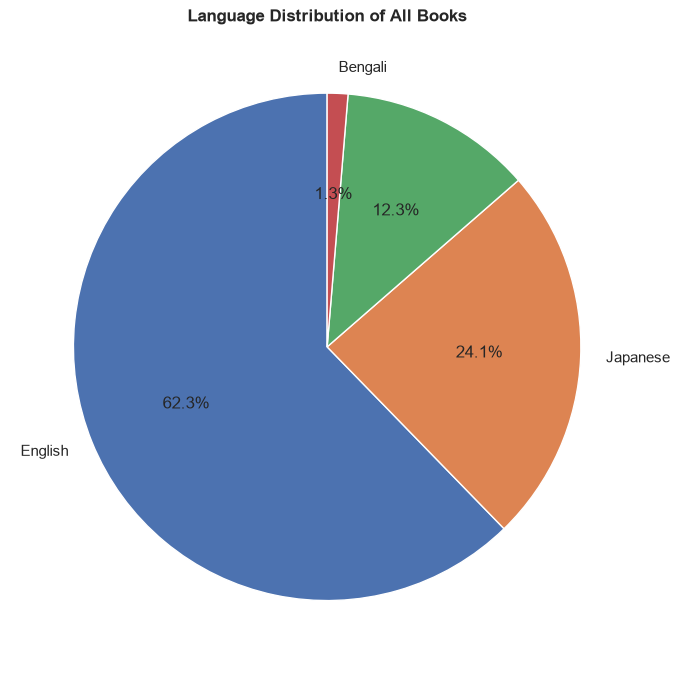

In [ ]:
# Language Distribution Pie Chart

plt.figure(figsize=(7, 7))

plt.pie(
    language_counts.values,
    labels=language_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Language Distribution of All Books",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


In [ ]:
# Book Type Distribution

type_counts = (
    df["Type"]
    .value_counts()
    .reset_index()
)

type_counts.columns = [
    "Type",
    "Count"
]

display(type_counts)


,Type,Count
0,Book,169
1,,40
2,Manga,16
3,Textbook,3


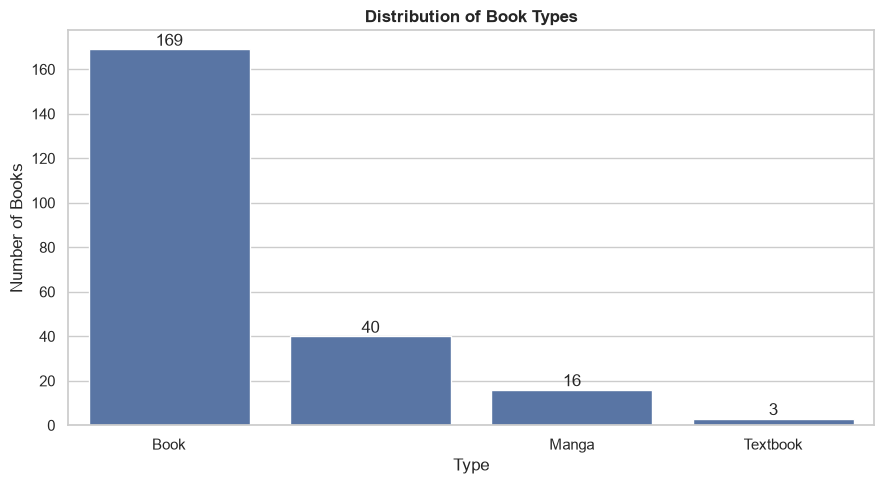

In [ ]:
# Book Type Visualisation

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=type_counts,
    x="Type",
    y="Count"
)

plt.title(
    "Distribution of Book Types",
    fontweight="bold"
)

plt.xlabel("Type")
plt.ylabel("Number of Books")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


In [ ]:
# Completed Books By Language

read_by_language = (
    books_read["Language"]
    .value_counts()
    .reset_index()
)

read_by_language.columns = [
    "Language",
    "Books_Read"
]

display(read_by_language)


,Language,Books_Read
0,English,37
1,Japanese,21


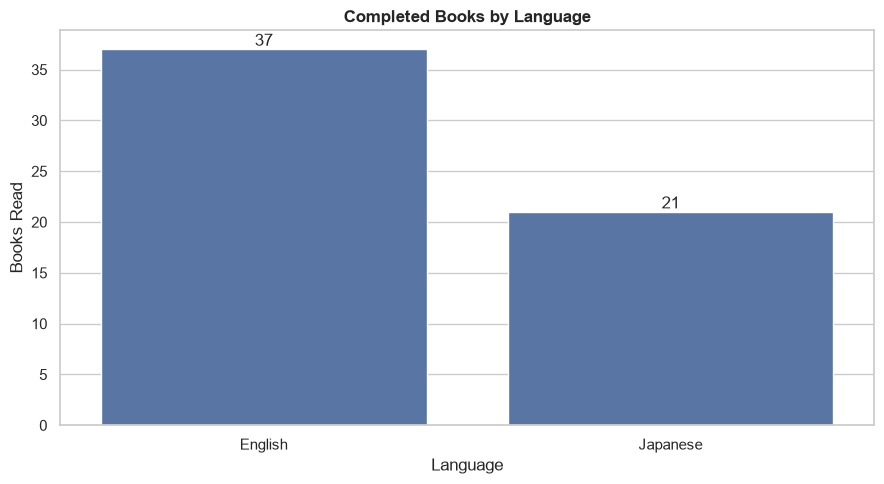

In [ ]:
# Completed Books By Language Visualisation

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=read_by_language,
    x="Language",
    y="Books_Read"
)

plt.title(
    "Completed Books by Language",
    fontweight="bold"
)

plt.xlabel("Language")
plt.ylabel("Books Read")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


In [ ]:
# Books Read By Year And Language

annual_stats = pd.crosstab(
    books_read["Reading_Year"],
    books_read["Language"]
)

# Add total number of books completed in each year.
annual_stats["Total"] = (
    annual_stats.sum(axis=1)
)

# Sort known years in descending order.
known_years = sorted(
    [
        year
        for year in annual_stats.index
        if year != 0
    ],
    reverse=True
)

annual_stats = annual_stats.reindex(
    known_years + [0]
)

annual_stats = (
    annual_stats
    .fillna(0)
    .astype(int)
)

display_stats = annual_stats.copy()

# Convert the internal 0.0 sentinel to the
# presentation-friendly "????" category.

display_stats.index = display_stats.index.map(
    lambda x:
        "????"
        if x == 0
        else str(int(x))
)

display(display_stats)


Language,English,Japanese,Total
Reading_Year,,,
2026,2,5,7
2025,8,10,18
2024,1,0,1
2023,2,0,2
2018,1,0,1
????,23,6,29


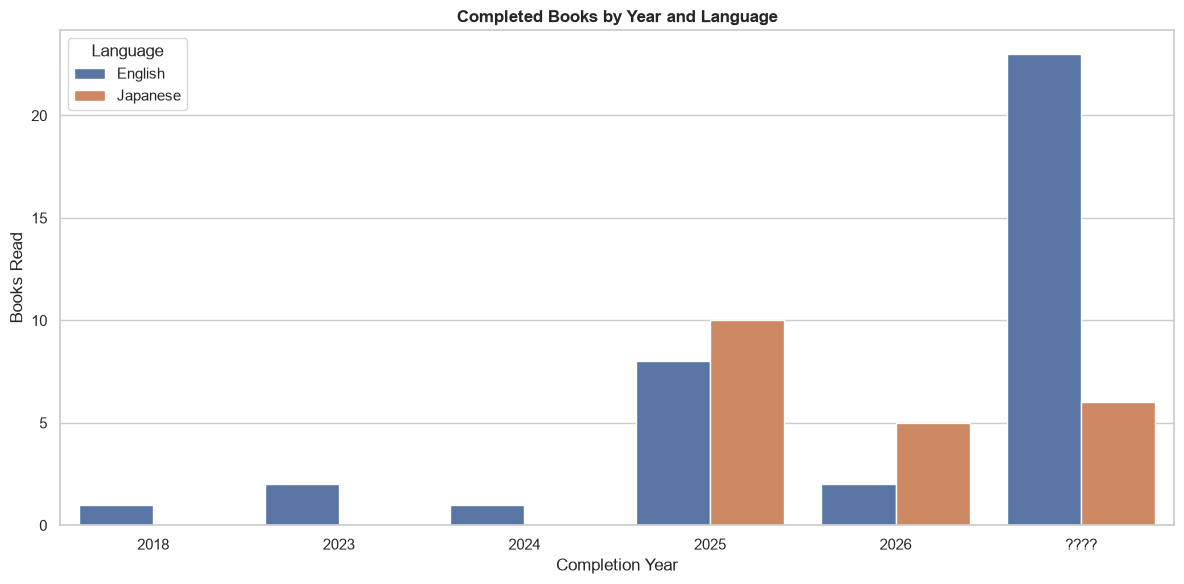

In [ ]:
# Annual Reading Volume By Language

plot_data = (
    books_read
    .groupby(
        ["Reading_Year", "Language"]
    )
    .size()
    .reset_index(name="Books_Read")
)


# Convert the analytical 0.0 value into a display label.
#
# Internally:
#     0.0 = unknown completion year
#
# For presentation:
#     0.0 -> "????"
#     2025 -> "2025"


plot_data["Year_Label"] = plot_data[
    "Reading_Year"
].apply(
    lambda x: "????"
    if x == 0
    else str(int(x))
)

# Sort years chronologically while keeping ???? at the end.

plot_data["Sort_Year"] = plot_data[
    "Reading_Year"
].replace(0, np.inf)

plot_data = plot_data.sort_values(
    "Sort_Year"
)

# Plot

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x="Year_Label",
    y="Books_Read",
    hue="Language"
)

plt.title(
    "Completed Books by Year and Language",
    fontweight="bold"
)

plt.xlabel("Completion Year")
plt.ylabel("Books Read")

plt.legend(
    title="Language"
)

plt.tight_layout()
plt.show()


In [ ]:
# Total Books Read By Year

yearly_reads = (
    books_read[
        books_read["Reading_Year"] > 0
    ]
    .groupby("Reading_Year")
    .size()
    .reset_index(name="Books_Read")
    .sort_values("Reading_Year")
)

display(yearly_reads)


,Reading_Year,Books_Read
0,"2,018.00",1
1,"2,023.00",2
2,"2,024.00",1
3,"2,025.00",18
4,"2,026.00",7


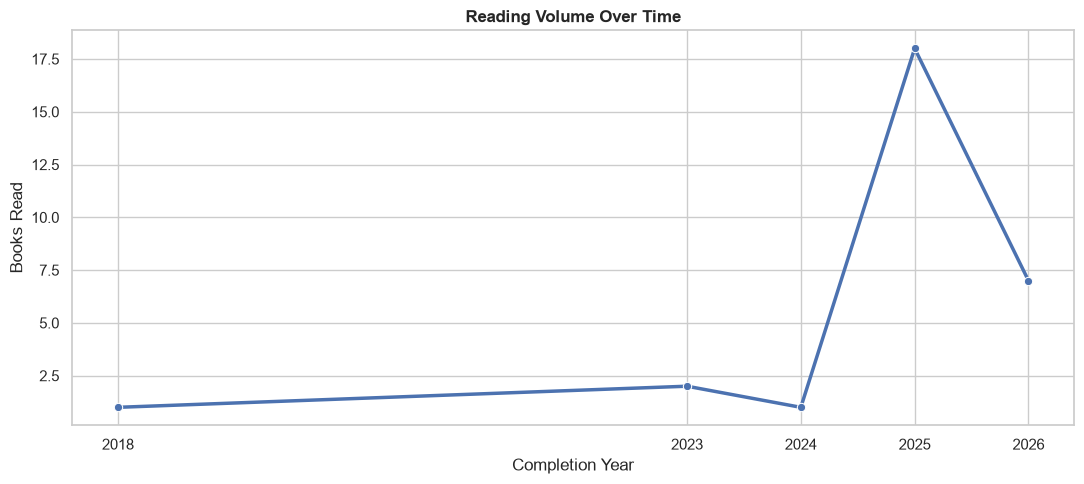

In [250]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=yearly_reads,
    x="Reading_Year",
    y="Books_Read",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Reading Volume Over Time",
    fontweight="bold"
)

plt.xlabel("Completion Year")
plt.ylabel("Books Read")

plt.xticks(
    yearly_reads["Reading_Year"]
)

plt.tight_layout()
plt.show()


,Year_Label,Books_Read
1,2018,1
2,2023,2
3,2024,1
4,2025,18
5,2026,7
0,????,29


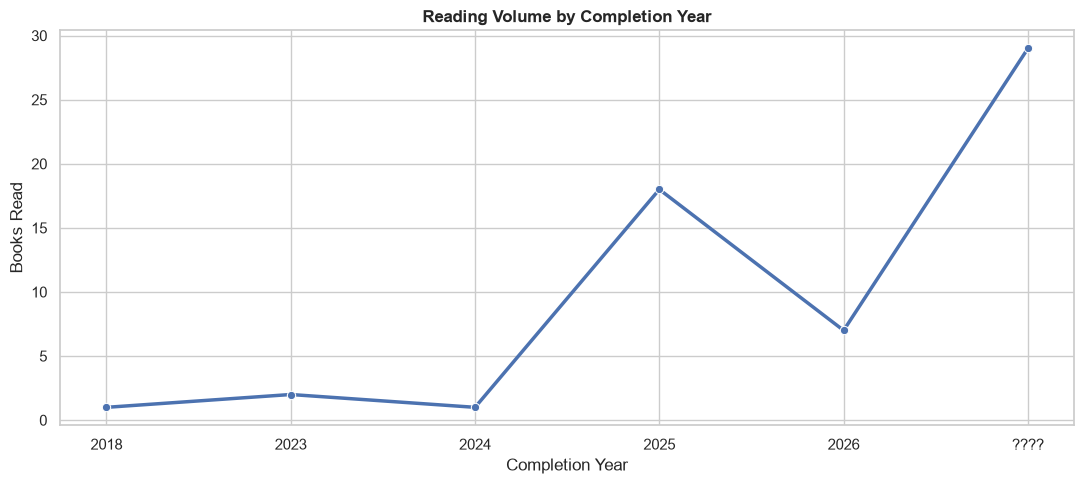

In [ ]:
# Total Books Read By Year

yearly_reads = (
    books_read
    .groupby("Reading_Year")
    .size()
    .reset_index(name="Books_Read")
)

# Create display labels
#
# 0.0 is the internal analytical representation of
# an unknown completion year.

yearly_reads["Year_Label"] = yearly_reads[
    "Reading_Year"
].apply(
    lambda x: "????"
    if x == 0
    else str(int(x))
)

# Sort known years chronologically and place ???? last.

yearly_reads["Sort_Order"] = yearly_reads[
    "Reading_Year"
].replace(0, np.inf)

yearly_reads = yearly_reads.sort_values(
    "Sort_Order"
)


display(
    yearly_reads[
        ["Year_Label", "Books_Read"]
    ]
)

# Visualisation

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=yearly_reads,
    x="Year_Label",
    y="Books_Read",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Reading Volume by Completion Year",
    fontweight="bold"
)

plt.xlabel("Completion Year")
plt.ylabel("Books Read")

plt.tight_layout()
plt.show()


In [ ]:
# Publication Year Analysis

publication_data = df[
    df["Publish_Year"].notna()
].copy()

print(
    f"Books with known publication year: "
    f"{len(publication_data):,}"
)

print(
    f"Median publication year: "
    f"{publication_data['Publish_Year'].median():.0f}"
)

print(
    f"Oldest publication year: "
    f"{publication_data['Publish_Year'].min():.0f}"
)

print(
    f"Newest publication year: "
    f"{publication_data['Publish_Year'].max():.0f}"
)


Books with known publication year: 20
Median publication year: 2008
Oldest publication year: 1847
Newest publication year: 2025


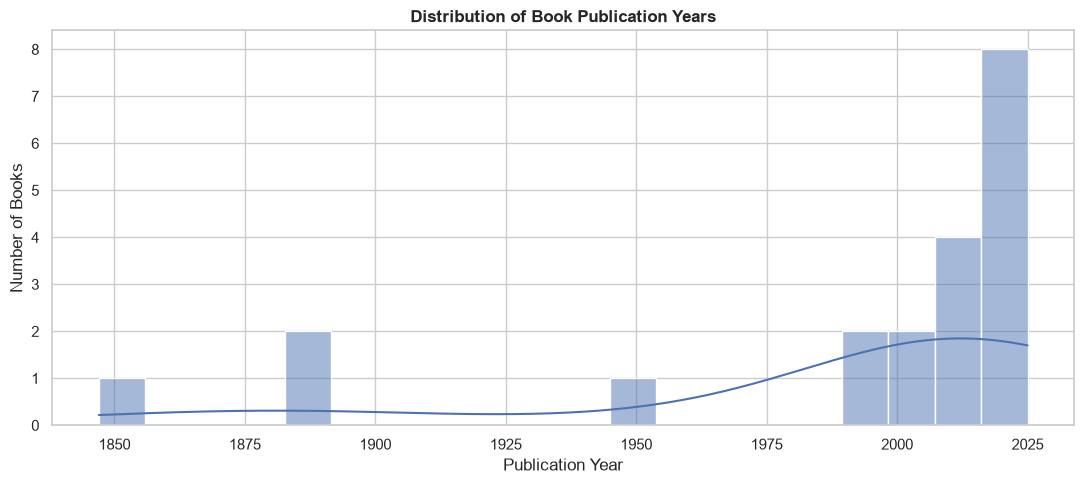

In [ ]:
# Publication Year Distribution

plt.figure(figsize=(11, 5))

sns.histplot(
    data=publication_data,
    x="Publish_Year",
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Book Publication Years",
    fontweight="bold"
)

plt.xlabel("Publication Year")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()


In [ ]:
# Summary Kpis

total_books = len(df)

total_read = df["Status"].eq("Read").sum()

total_tbr = df["Status"].eq("To Be Read").sum()

unknown_reading_year = (
    books_read["Reading_Year"].eq(0).sum()
)

known_reading_year = (
    books_read["Reading_Year"].gt(0).sum()
)

summary_kpis = pd.DataFrame({
    "Metric": [
        "Total books tracked",
        "Books read",
        "Books to be read",
        "Books read with known completion year",
        "Books read with unknown completion year"
    ],
    "Value": [
        total_books,
        total_read,
        total_tbr,
        known_reading_year,
        unknown_reading_year
    ]
})

display(summary_kpis)


,Metric,Value
0,Total books tracked,228
1,Books read,58
2,Books to be read,166
3,Books read with known completion year,29
4,Books read with unknown completion year,29


In [ ]:
# Completion Month Data Availability

month_data = books_read[
    books_read["Finish_Month"].notna()
].copy()

print(
    f"Completed books: {len(books_read):,}"
)

print(
    f"Books with known completion month: "
    f"{len(month_data):,}"
)

print(
    f"Books with unknown completion month: "
    f"{books_read['Finish_Month'].isna().sum():,}"
)

print(
    f"Percentage with known completion month: "
    f"{len(month_data) / len(books_read) * 100:.1f}%"
)


Completed books: 58
Books with known completion month: 24
Books with unknown completion month: 34
Percentage with known completion month: 41.4%


In [ ]:
# Books Completed By Month

monthly_reads = (
    month_data
    .groupby("Finish_Month")
    .size()
    .reindex(range(1, 13), fill_value=0)
    .reset_index(name="Books_Read")
)

monthly_reads["Month"] = monthly_reads[
    "Finish_Month"
].map({
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
})

display(
    monthly_reads[
        ["Finish_Month", "Month", "Books_Read"]
    ]
)


,Finish_Month,Month,Books_Read
0,1,January,2
1,2,February,0
2,3,March,1
3,4,April,0
4,5,May,2
5,6,June,9
6,7,July,2
7,8,August,2
8,9,September,1
9,10,October,2


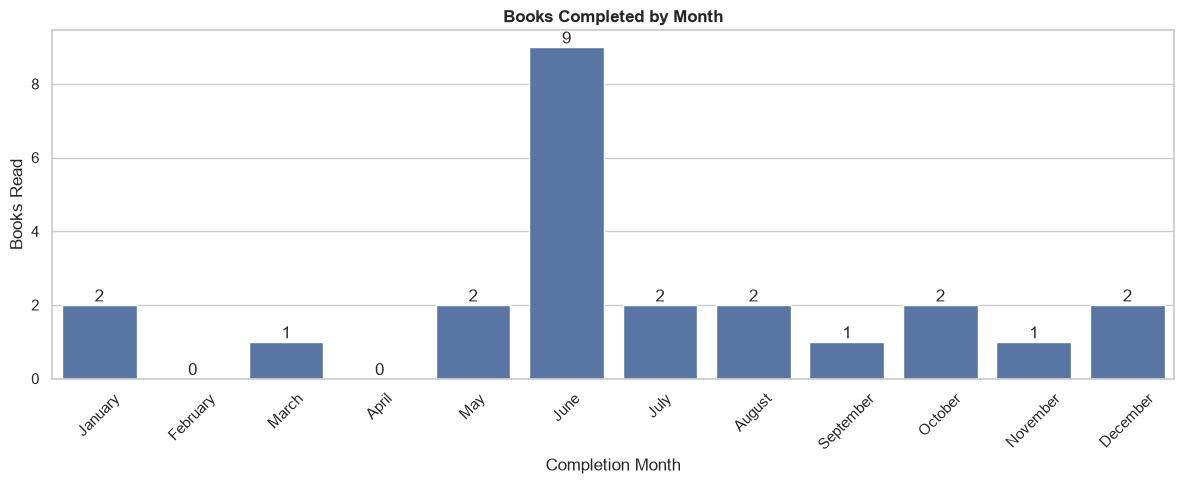

In [ ]:
# Monthly Completion Volume

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=monthly_reads,
    x="Month",
    y="Books_Read"
)

plt.title(
    "Books Completed by Month",
    fontweight="bold"
)

plt.xlabel("Completion Month")
plt.ylabel("Books Read")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


In [ ]:
# Monthly Share Of Completions

monthly_reads["Percentage"] = (
    monthly_reads["Books_Read"]
    / monthly_reads["Books_Read"].sum()
    * 100
)

display(
    monthly_reads[
        ["Month", "Books_Read", "Percentage"]
    ]
)


,Month,Books_Read,Percentage
0,January,2,8.33
1,February,0,0.00
2,March,1,4.17
3,April,0,0.00
4,May,2,8.33
5,June,9,37.50
6,July,2,8.33
7,August,2,8.33
8,September,1,4.17
9,October,2,8.33


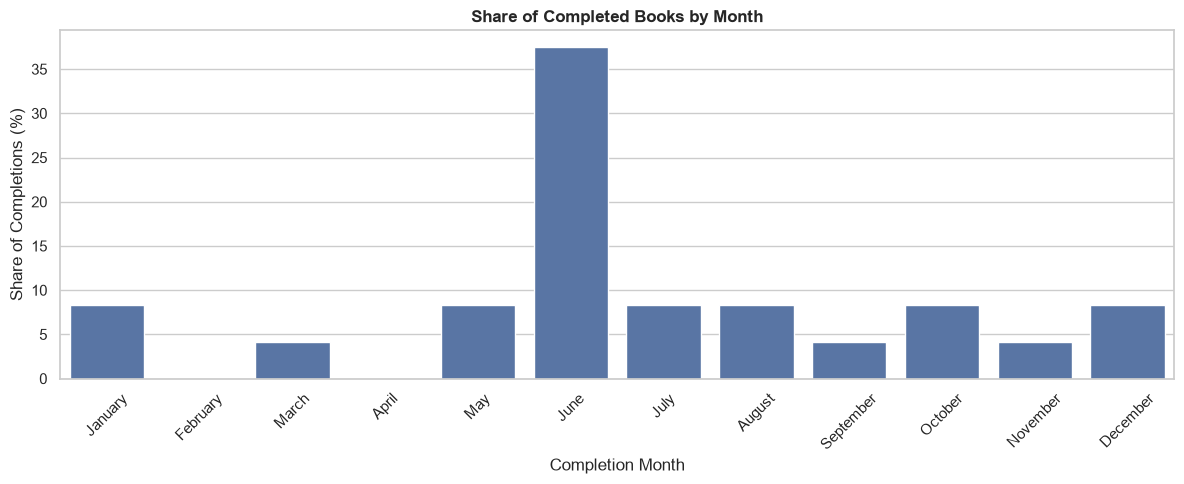

In [ ]:
# Monthly Completion Share

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=monthly_reads,
    x="Month",
    y="Percentage"
)

plt.title(
    "Share of Completed Books by Month",
    fontweight="bold"
)

plt.xlabel("Completion Month")
plt.ylabel("Share of Completions (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# Year × Month Completion Matrix

year_month_data = books_read[
    (books_read["Reading_Year"] > 0)
    & (books_read["Finish_Month"].notna())
].copy()

year_month_data["Reading_Year"] = (
    year_month_data["Reading_Year"]
    .astype(int)
)

year_month_counts = pd.crosstab(
    year_month_data["Reading_Year"],
    year_month_data["Finish_Month"]
)

# Ensure all months exist as columns.
year_month_counts = (
    year_month_counts
    .reindex(columns=range(1, 13), fill_value=0)
)

year_month_counts.columns = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

display(year_month_counts)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Reading_Year,,,,,,,,,,,,
2025,0,0,0,0,2,6,2,1,1,2,1,2
2026,2,0,1,0,0,3,0,1,0,0,0,0


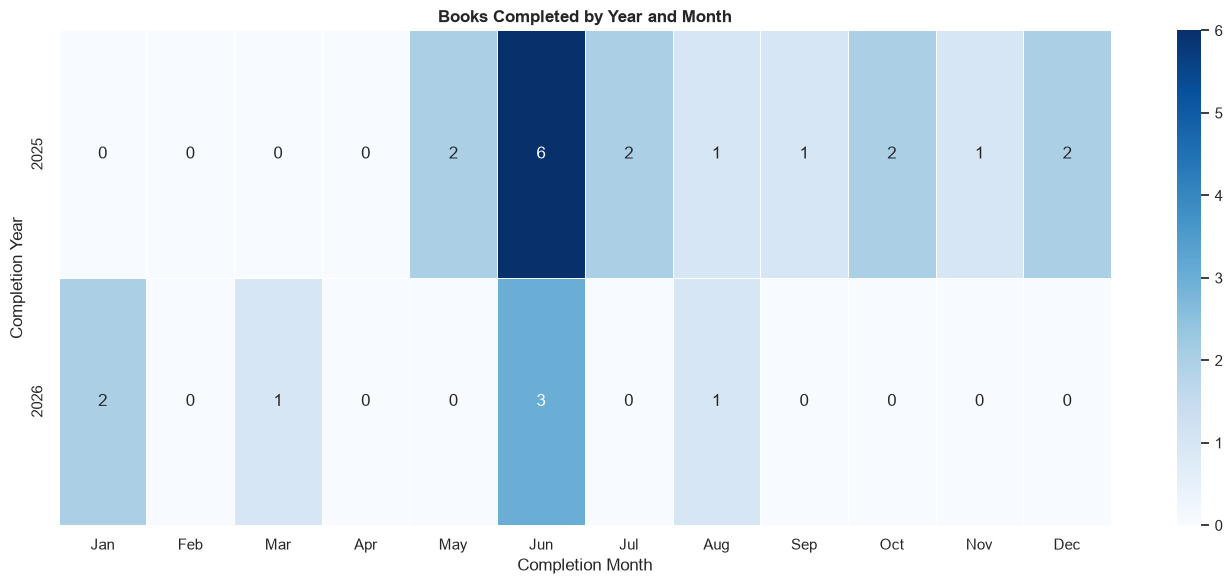

In [ ]:
# Year × Month Heatmap

plt.figure(figsize=(14, 6))

sns.heatmap(
    year_month_counts,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title(
    "Books Completed by Year and Month",
    fontweight="bold"
)

plt.xlabel("Completion Month")
plt.ylabel("Completion Year")

plt.tight_layout()
plt.show()


In [ ]:
# Monthly Distribution Within Each Year

year_month_percentage = (
    year_month_counts
    .div(
        year_month_counts.sum(axis=1),
        axis=0
    )
    * 100
)

display(
    year_month_percentage.round(1)
)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Reading_Year,,,,,,,,,,,,
2025,0.00,0.00,0.00,0.00,11.80,35.30,11.80,5.90,5.90,11.80,5.90,11.80
2026,28.60,0.00,14.30,0.00,0.00,42.90,0.00,14.30,0.00,0.00,0.00,0.00


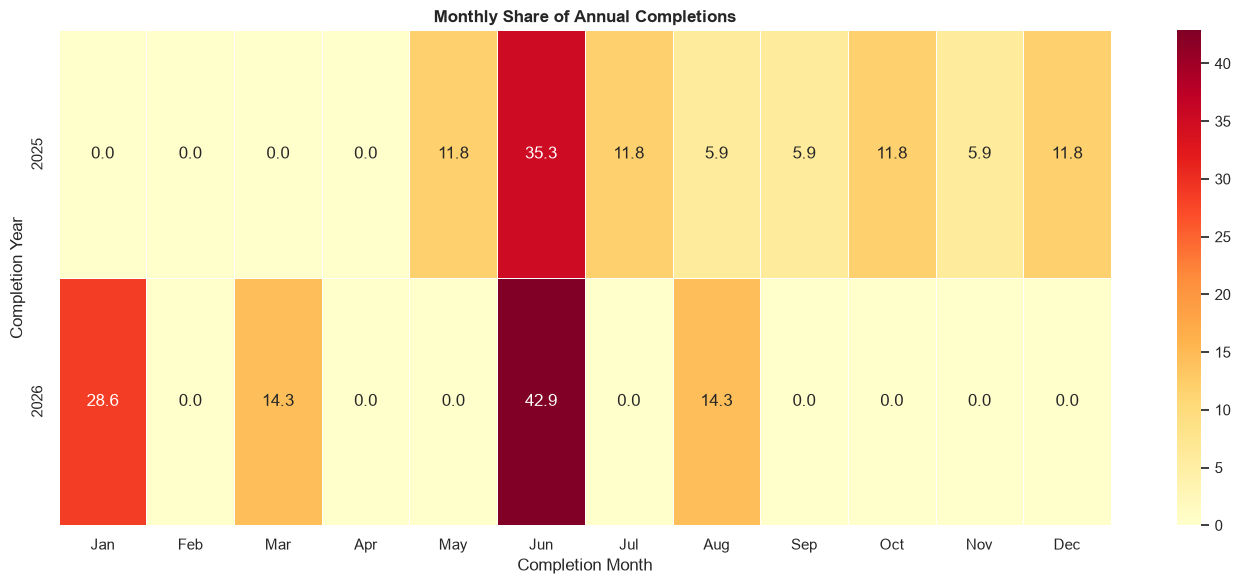

In [ ]:
# Monthly Seasonality By Year

plt.figure(figsize=(14, 6))

sns.heatmap(
    year_month_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title(
    "Monthly Share of Annual Completions",
    fontweight="bold"
)

plt.xlabel("Completion Month")
plt.ylabel("Completion Year")

plt.tight_layout()
plt.show()


In [ ]:
# Average Monthly Completion Volume

monthly_yearly_average = (
    year_month_counts
    .mean(axis=0)
    .reset_index()
)

monthly_yearly_average.columns = [
    "Month",
    "Average_Books_Read"
]

display(
    monthly_yearly_average
    .sort_values(
        "Average_Books_Read",
        ascending=False
    )
)


,Month,Average_Books_Read
5,Jun,4.50
0,Jan,1.00
4,May,1.00
6,Jul,1.00
9,Oct,1.00
11,Dec,1.00
7,Aug,1.00
2,Mar,0.50
8,Sep,0.50
10,Nov,0.50


In [ ]:
# Start Month Vs Completion Month

# Books with an explicitly recorded start month.
started_books = books_read[
    books_read["Start_Month"].notna()
].copy()

# Books with an explicitly recorded completion month.
finished_books = books_read[
    books_read["Finish_Month"].notna()
].copy()


print(
    f"Books with known start month: "
    f"{len(started_books):,}"
)

print(
    f"Books with known completion month: "
    f"{len(finished_books):,}"
)


Books with known start month: 24
Books with known completion month: 24


In [ ]:
# Monthly Start Vs Completion Counts

start_counts = (
    started_books["Start_Month"]
    .value_counts()
    .reindex(range(1, 13), fill_value=0)
)

finish_counts = (
    finished_books["Finish_Month"]
    .value_counts()
    .reindex(range(1, 13), fill_value=0)
)


monthly_comparison = pd.DataFrame({
    "Books_Started": start_counts,
    "Books_Completed": finish_counts
})

monthly_comparison.index.name = "Month"

monthly_comparison["Month_Name"] = monthly_comparison.index.map({
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
})

display(
    monthly_comparison[
        [
            "Month_Name",
            "Books_Started",
            "Books_Completed"
        ]
    ]
)


,Month_Name,Books_Started,Books_Completed
Month,,,
1,January,2,2
2,February,0,0
3,March,0,1
4,April,0,0
5,May,3,2
6,June,8,9
7,July,4,2
8,August,1,2
9,September,3,1


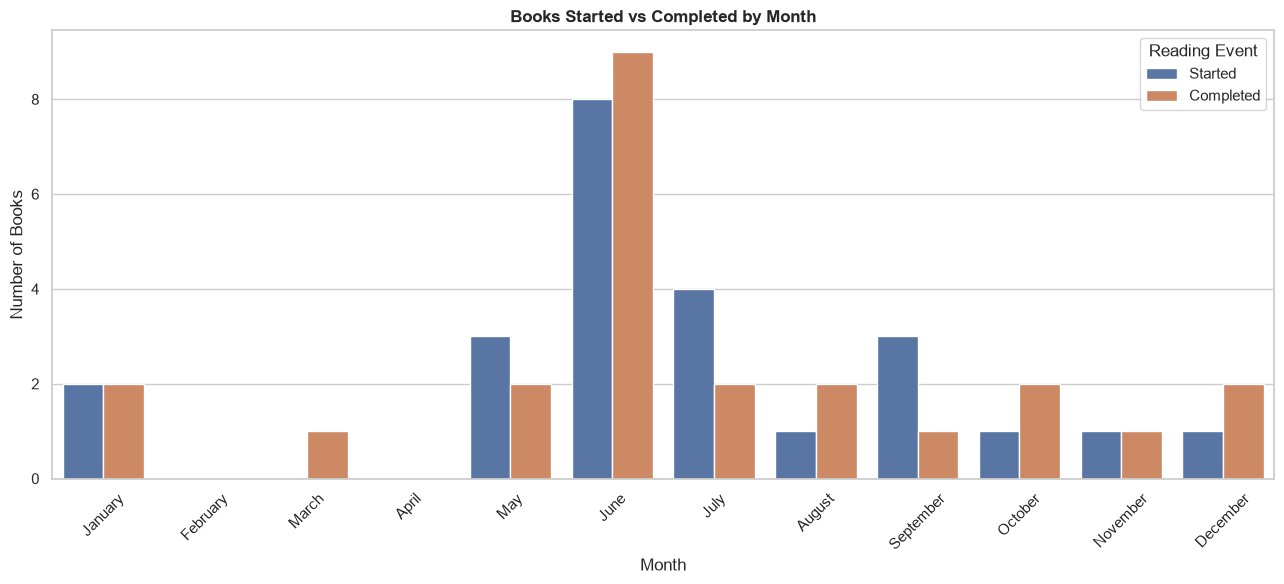

In [ ]:
# Start Vs Completion Month

plot_comparison = (
    monthly_comparison
    .reset_index()
    .melt(
        id_vars=["Month", "Month_Name"],
        value_vars=[
            "Books_Started",
            "Books_Completed"
        ],
        var_name="Event",
        value_name="Books"
    )
)

plot_comparison["Event"] = (
    plot_comparison["Event"]
    .map({
        "Books_Started": "Started",
        "Books_Completed": "Completed"
    })
)


plt.figure(figsize=(13, 6))

sns.barplot(
    data=plot_comparison,
    x="Month_Name",
    y="Books",
    hue="Event"
)

plt.title(
    "Books Started vs Completed by Month",
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Books")

plt.xticks(rotation=45)

plt.legend(
    title="Reading Event"
)

plt.tight_layout()
plt.show()


In [ ]:
# Normalised Start Vs Completion Distributions

monthly_comparison["Started_Percentage"] = (
    monthly_comparison["Books_Started"]
    / monthly_comparison["Books_Started"].sum()
    * 100
)

monthly_comparison["Completed_Percentage"] = (
    monthly_comparison["Books_Completed"]
    / monthly_comparison["Books_Completed"].sum()
    * 100
)

display(
    monthly_comparison[
        [
            "Month_Name",
            "Started_Percentage",
            "Completed_Percentage"
        ]
    ].round(1)
)


,Month_Name,Started_Percentage,Completed_Percentage
Month,,,
1,January,8.30,8.30
2,February,0.00,0.00
3,March,0.00,4.20
4,April,0.00,0.00
5,May,12.50,8.30
6,June,33.30,37.50
7,July,16.70,8.30
8,August,4.20,8.30
9,September,12.50,4.20


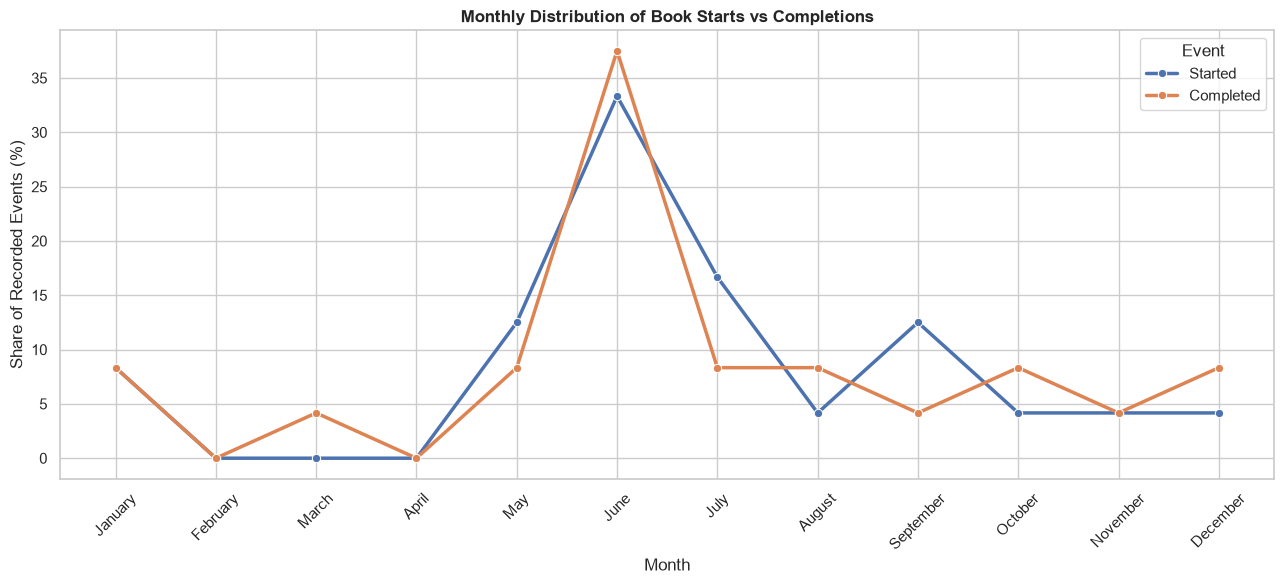

In [ ]:
# Normalised Start Vs Completion Distributions

percentage_plot = (
    monthly_comparison
    .reset_index()
    .melt(
        id_vars=["Month", "Month_Name"],
        value_vars=[
            "Started_Percentage",
            "Completed_Percentage"
        ],
        var_name="Event",
        value_name="Percentage"
    )
)

percentage_plot["Event"] = (
    percentage_plot["Event"]
    .map({
        "Started_Percentage": "Started",
        "Completed_Percentage": "Completed"
    })
)


plt.figure(figsize=(13, 6))

sns.lineplot(
    data=percentage_plot,
    x="Month_Name",
    y="Percentage",
    hue="Event",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Monthly Distribution of Book Starts vs Completions",
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Share of Recorded Events (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# Start Month × Completion Month

start_finish_data = books_read[
    books_read["Start_Month"].notna()
    & books_read["Finish_Month"].notna()
].copy()

start_finish_matrix = pd.crosstab(
    start_finish_data["Start_Month"],
    start_finish_data["Finish_Month"]
)

# Ensure all 12 months are represented.
start_finish_matrix = (
    start_finish_matrix
    .reindex(index=range(1, 13), fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)
)

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

start_finish_matrix.index = month_names
start_finish_matrix.columns = month_names

display(start_finish_matrix)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Jan,2,0,0,0,0,0,0,0,0,0,0,0
Feb,0,0,0,0,0,0,0,0,0,0,0,0
Mar,0,0,0,0,0,0,0,0,0,0,0,0
Apr,0,0,0,0,0,0,0,0,0,0,0,0
May,0,0,0,0,2,1,0,0,0,0,0,0
Jun,0,0,0,0,0,8,0,0,0,0,0,0
Jul,0,0,0,0,0,0,2,2,0,0,0,0
Aug,0,0,0,0,0,0,0,0,1,0,0,0
Sep,0,0,1,0,0,0,0,0,0,2,0,0
Oct,0,0,0,0,0,0,0,0,0,0,1,0


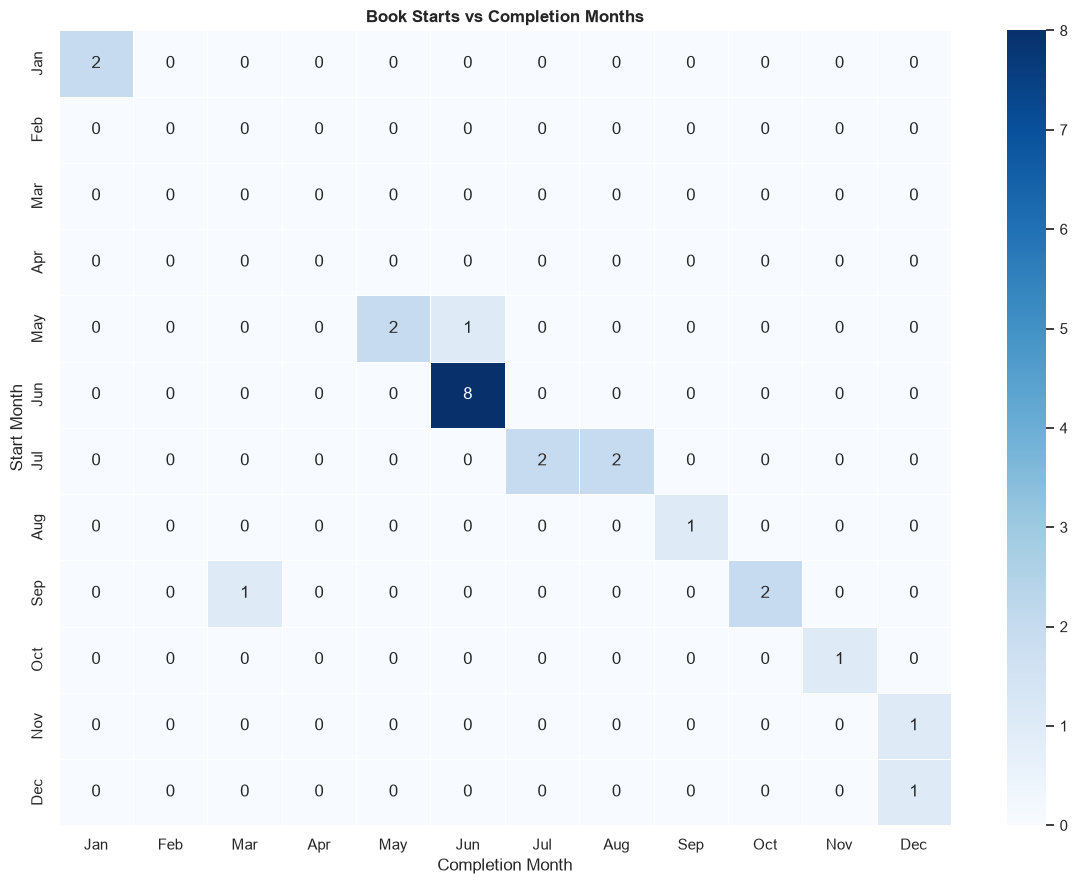

In [ ]:
# Start Month × Completion Month Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    start_finish_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title(
    "Book Starts vs Completion Months",
    fontweight="bold"
)

plt.xlabel("Completion Month")
plt.ylabel("Start Month")

plt.tight_layout()
plt.show()
